In [81]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [82]:
df = pd.read_csv("smartcart_customers.csv")

# Data Preprocessing

In [83]:
# Handle Missing values
df["Income"] = pd.to_numeric(df["Income"], errors = "coerce") # This will ensure that column will have all 
# the columns converted to numeric and all NULL values will get converted into NAN 
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [84]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [85]:
# Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_tenure"] = (reference_date - df["Dt_Customer"]).dt.days

In [86]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [87]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [123]:
# Total Childrens
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [89]:
df["Education"].value_counts()

# convert education data into 3 categoris UG, graduate and post Graduate
df["Education"] = df["Education"].replace({
    "Basic" : "UnderGraduate", "2n Cycle" : "UnderGraduate",
    "Graduation" : "Graduate",
    "Master" : "PostGraduate" , "PhD" : "PostGraduate" 
})

In [90]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner",
    "Single" : "Alone", "Divorced" : "Alone",
    "Widow" : "Alone" , "Absurd" : "Alone", "YOLO" : "Alone" 
})

In [91]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [92]:
df_cleaned.shape

(2240, 15)

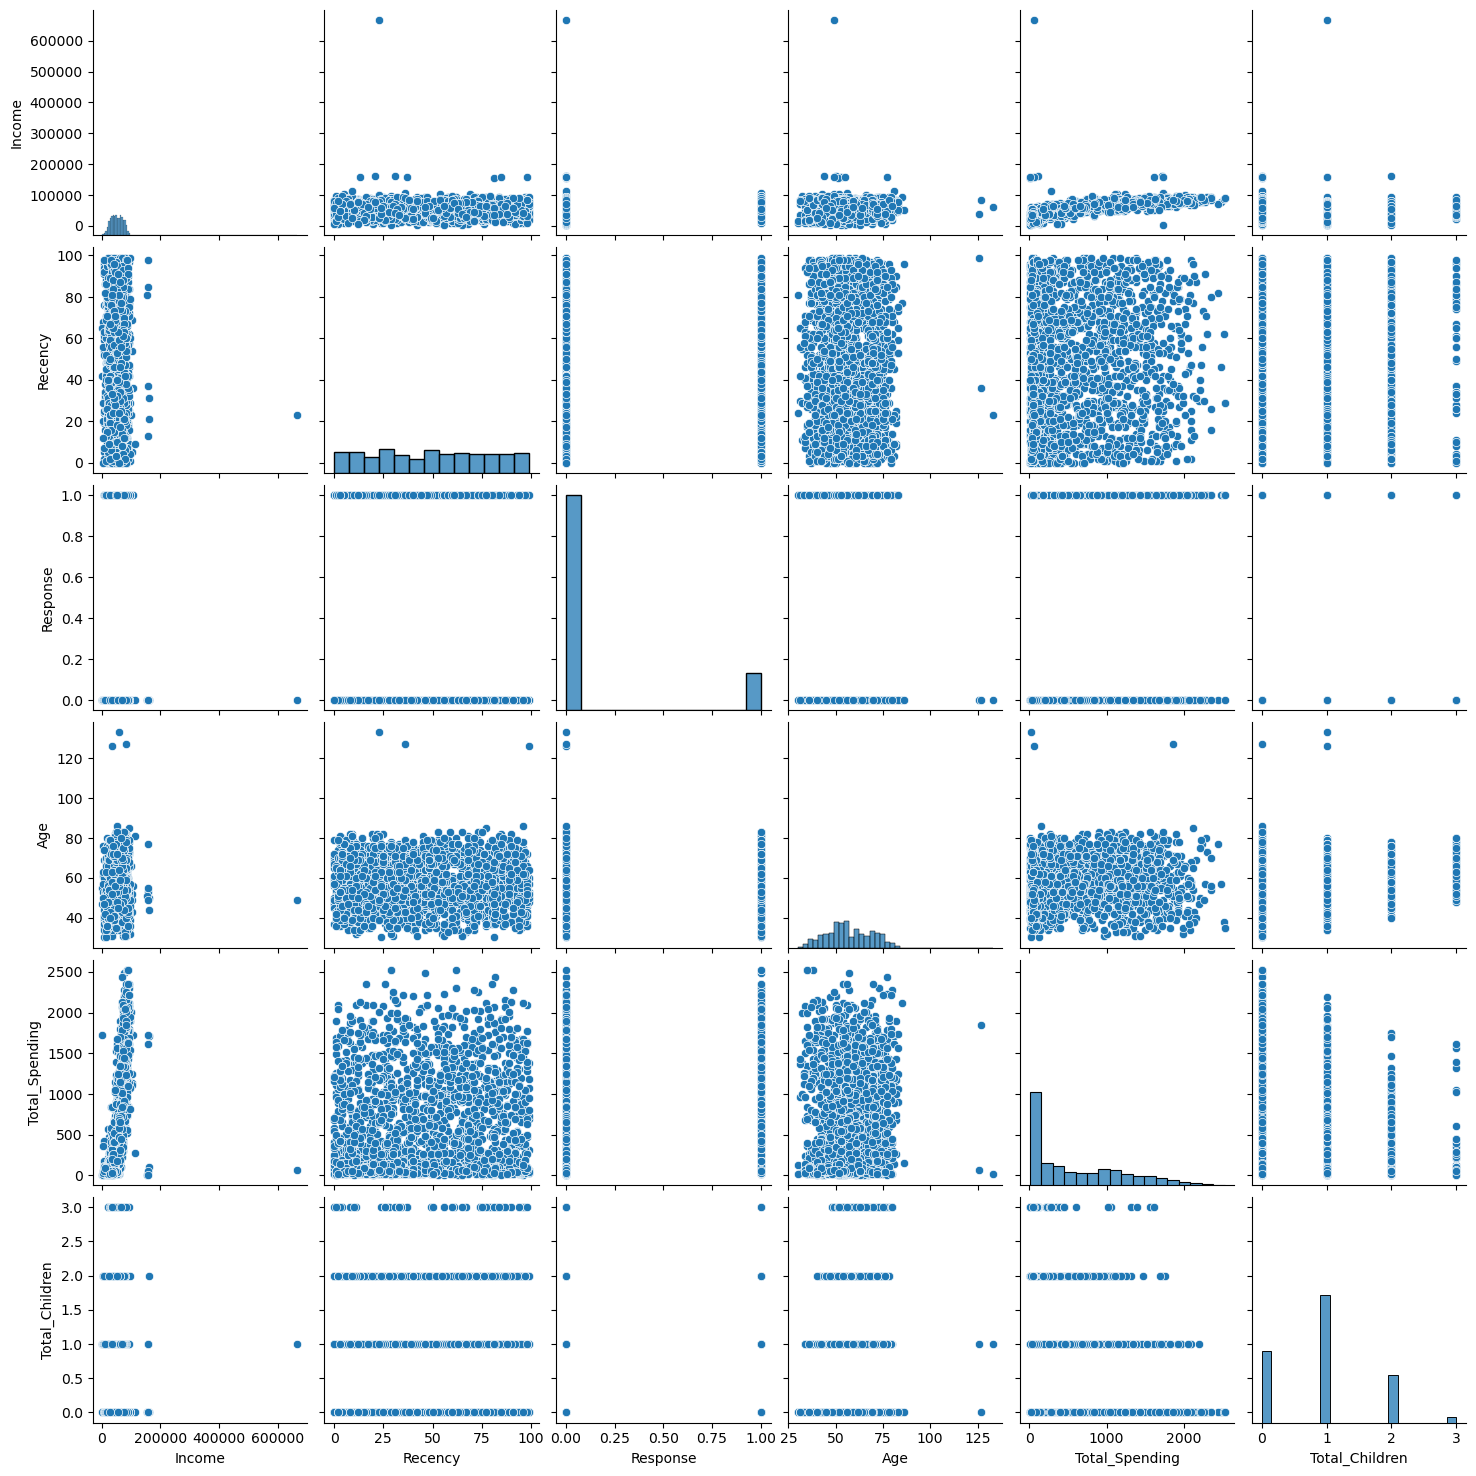

In [93]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]
# Relative plots of some features - pair plots

sns.pairplot(df_cleaned[cols])

In [94]:
# Remove Outliers
print("Data with Outliers : ", len(df_cleaned))
df_cleaned = df_cleaned.query("Age < 90")
df_cleaned = df_cleaned.query("Income < 600_000")
print("Data without Outliers : ", len(df_cleaned))

Data with Outliers :  2240
Data without Outliers :  2236


# HeatMap

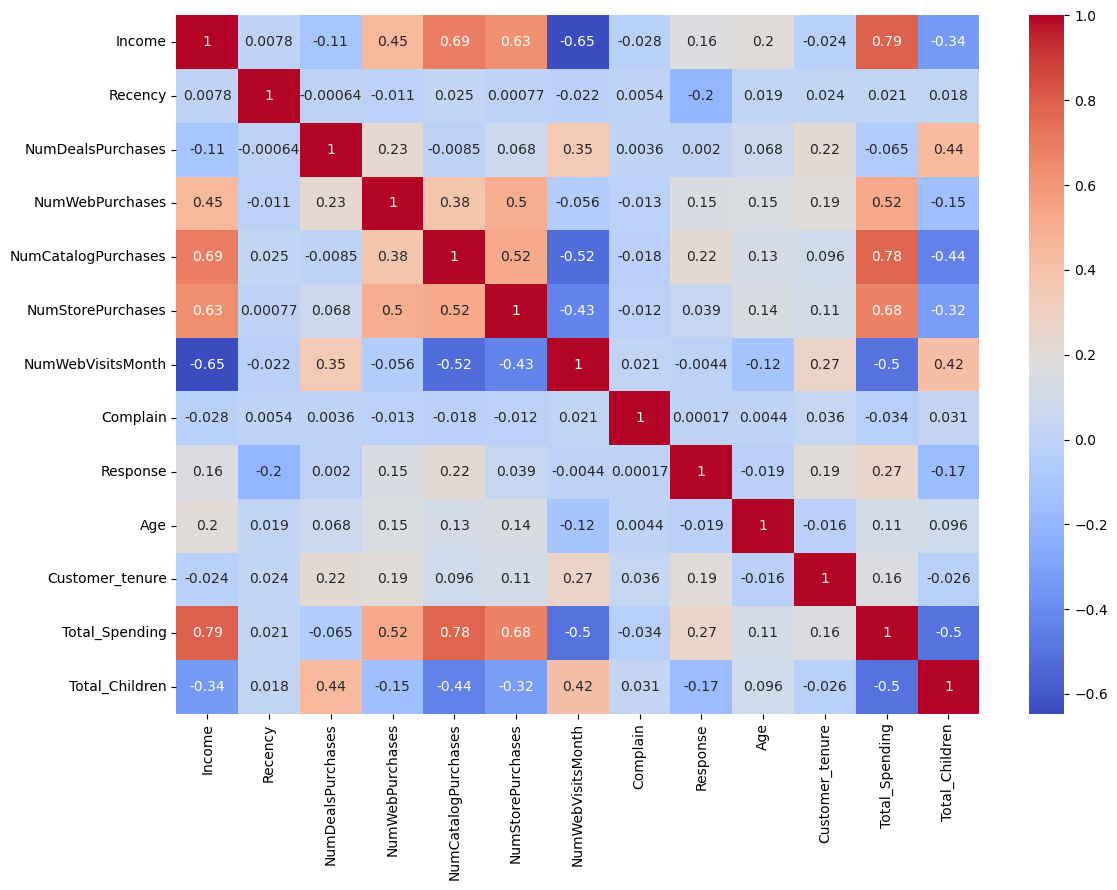

In [95]:
corr = df_cleaned.corr(numeric_only = True)

plt.figure(figsize = (12, 9))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)
plt.tight_layout()

In [96]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Feature Encoding

In [97]:
from sklearn.preprocessing import OneHotEncoder

In [98]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])
df_encoded = pd.DataFrame(encoded_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [99]:
df_encoded

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [100]:
df_cleaned = pd.concat([df_cleaned.drop(columns = cat_cols), df_encoded], axis = 1)

In [101]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2236 non-null   float64
 1   Recency                  2236 non-null   int64  
 2   NumDealsPurchases        2236 non-null   int64  
 3   NumWebPurchases          2236 non-null   int64  
 4   NumCatalogPurchases      2236 non-null   int64  
 5   NumStorePurchases        2236 non-null   int64  
 6   NumWebVisitsMonth        2236 non-null   int64  
 7   Complain                 2236 non-null   int64  
 8   Response                 2236 non-null   int64  
 9   Age                      2236 non-null   int64  
 10  Customer_tenure          2236 non-null   int64  
 11  Total_Spending           2236 non-null   int64  
 12  Total_Children           2236 non-null   int64  
 13  Education_Graduate       2236 non-null   float64
 14  Education_PostGraduate   2236

In [102]:
X = df_cleaned

In [103]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize

In [124]:
# 3D Visualization
from sklearn.decomposition import PCA

In [105]:
pca = PCA(
    n_components = 3
)
X_pca = pca.fit_transform(X_scaled)

In [126]:
print(pca.explained_variance_ratio_.sum())

0.4495442703569007


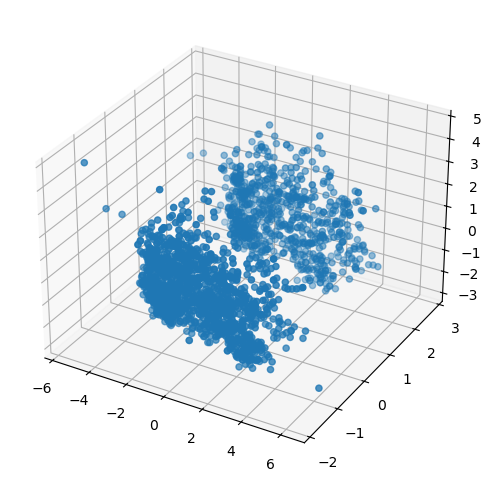

In [106]:
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2]
)

In [107]:
# analyze K value by elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42
    )
    labels = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [108]:
knee = KneeLocator(range(1, 11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.knee
print(optimal_k)

4


F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

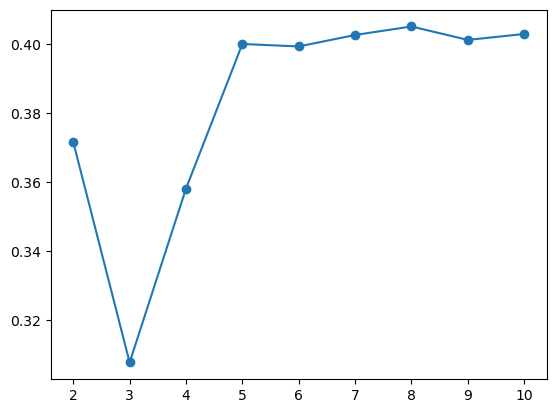

In [109]:
# Silhouette Score
from sklearn.metrics import silhouette_score
scores = []
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42
    )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker = "o")

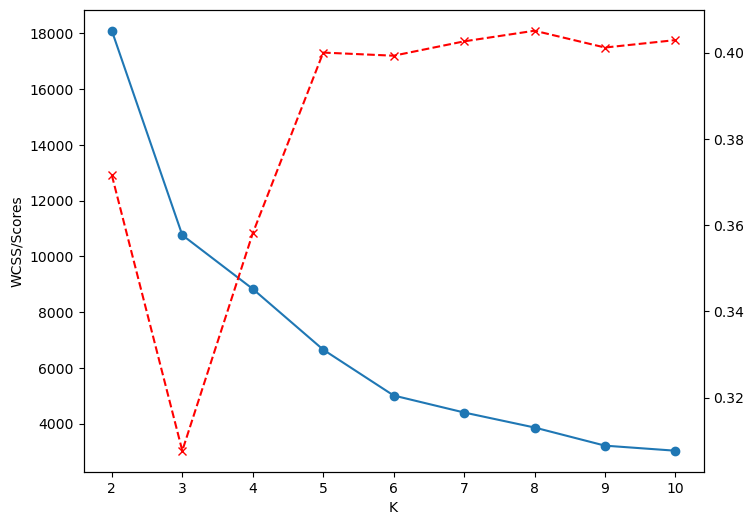

In [110]:
# Combine plot for elbow method and silhouette score
k_range = range(2, 11)
fig, ax1 = plt.subplots(figsize = (8, 6))
ax1.plot(k_range, wcss[0:len(k_range)], marker = "o")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS/Scores")
ax2 = ax1.twinx()
ax2.plot(k_range, scores[0:len(k_range)], marker = "x", linestyle = "--", color = "red")

In [111]:
# Trying Different Algorithms
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42
)
labels_kmeans = kmeans.fit_predict(X_pca)

F:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


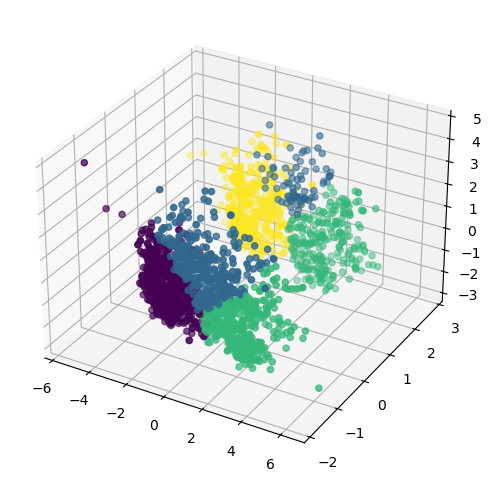

In [112]:
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c = labels_kmeans
)

In [113]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

agg_Cl = AgglomerativeClustering(
    n_clusters = 4,
    linkage = "ward"
)
labels_agg = agg_Cl.fit_predict(X_pca)

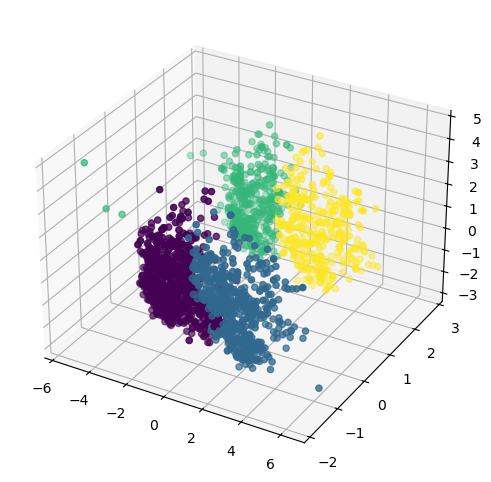

In [114]:
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c = labels_agg
)

In [122]:
print("KMeans:      ", silhouette_score(X_pca, labels_kmeans))
print("Agglomerative:", silhouette_score(X_pca, labels_agg))

KMeans:       0.35809961595980194
Agglomerative: 0.3792545615707473


In [121]:
# Agglomerative Clustering is better than KMeans
# Characterization of clusters
df_cleaned["clusters"] = labels_agg

In [116]:
df_cleaned.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

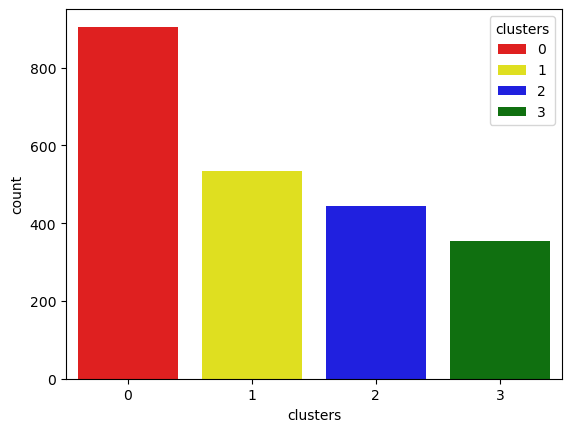

In [117]:
pal = ["red", "yellow", "blue", "green"]
sns.countplot(x = df_cleaned["clusters"], palette = pal, hue = df_cleaned["clusters"])

In [118]:
df_cleaned.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Total_Spending', ylabel='Income'>

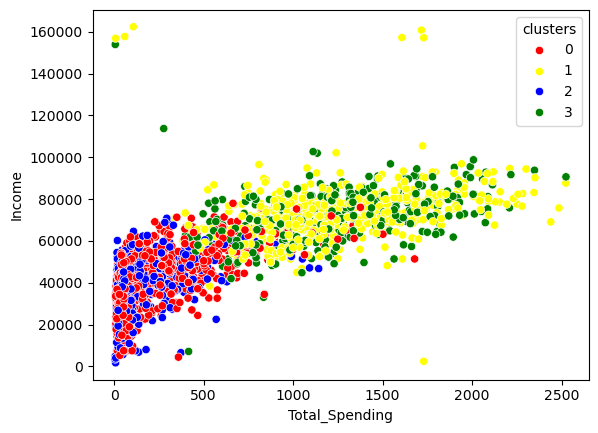

In [119]:
sns.scatterplot(x=df_cleaned["Total_Spending"], y=df_cleaned["Income"], hue=df_cleaned["clusters"], palette = pal)

In [120]:
cluster_summary = df_cleaned.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure  Total_Spending  \
clusters

##### Cluster 1 and 3 are premium customer for SmartCart
##### Cluster 0 and 2 are customer for SmartCart with less Income
##### c1 and c3 have higher income, more spending, less children, higher age, more shopping through store, 
##### c3 have best response, c1 have moderate response, c0 have average response, c2 have poor response
##### c0 and c1 are mostly living with their partners while c2 and c2 are mostly living alone
##### c1 and c3 are less web visitors and max store purchases and catalog purchases


##### c0 are family shoppers so we can offer discounts
##### c1 are premium customer and so we can offer loyalty to them
##### c2 are digital browsers and can be targeted for sales
##### c3 is a golden cluster and our majority focus so be on this. This cluster has best ROI. We can offer premium services